# Inventory resolution and hourly LCIA

SHRECC writes annual or monthly electricity inventories to Brightway. Hourly mixes remain calculation data: `NewDatabase.lcia()` assesses them directly without creating thousands of foreground activities.

In [1]:
from shrecc import NewDatabase

%load_ext jupyter_black

## Configuration

In [2]:
year = 2021
countries = ["ES"]
time_range = ["2021-01-01 00:00:00", "2021-06-30 23:00:00"]

project_name = "SHRECCei311"
bg_db_name = "ecoinvent-3.11-cutoff"
my_db_name = "spain_2021_monthly"

## Monthly inventories

Each month is aggregated and normalized independently. The configured `consumption_profile` supplies the weights within each month. Use the default `inventory_resolution="annual"` to create one inventory per country and year instead.

In [3]:
electricity = NewDatabase(
    years=year,
    countries=countries,
    time_range=time_range,
    project_name=project_name,
    bg_db_name=bg_db_name,
    my_db_name=my_db_name,
    inventory_resolution="monthly",
    consumption_profile="flat",
    include_consumption_mix_volume=False,
    retain_hourly_results=True,
)

In [4]:
electricity.create()
electricity.table().head()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_11128\3803269410.py:1: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: ES 1.5%. Largest source-technology gaps: ES/Waste non-renewable 1.0%, ES/Other renewables 0.3%, ES/Others 0.2%, FR/Waste non-renewable 0.0%, PT/Others 0.0%. See mapping_report(2021) for the full report.
  electricity.create()


time                                                                                   2021-01-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-02-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-03-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-04-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage electricity, high voltage kWh         0.0   

time                                                                                   2021-05-01  \
country                                                                                        ES   
geography activityName                                  product                   unit              
AL        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AM        electricity, high voltage, production mix     electricity, high voltage kWh         0.0   
AT        electricity production, deep geothermal       electricity, high voltage kWh         0.0   
          electricity production, hard coal             electricity, high voltage kWh         0.0   
          electricity production, hydro, pumped storage e

In [5]:
electricity.write()

100%|██████████| 6/6 [00:00<00:00, 396.67it/s]


15:45:41+0200 [info     ] Vacuuming database            


NewDatabase(years=[2021], sources={2021:energy_charts})

## Hourly LCIA

With no explicit methods, SHRECC uses every installed method in the exact `EF v3.1` family. The default engine scores each unique background input once and combines these scores with the hourly coefficients.

In [6]:
assessment = electricity.lcia()

In [ ]:
hourly = assessment.hourly()
annual = assessment.annual()
monthly = assessment.monthly()

<xarray.DataArray 'intensity' (time: 4344, consumer_country: 1,
                               impact_category: 25)> Size: 869kB
array([[[6.66423072e-04, 1.43342190e-01, 1.03882174e-03, ...,
         3.85941839e-09, 4.66242598e-04, 2.62775450e-01]],

       [[6.74236157e-04, 1.38335784e-01, 8.52186488e-04, ...,
         3.94765780e-09, 4.62219746e-04, 2.21720087e-01]],

       [[6.74518205e-04, 1.31728963e-01, 6.75415553e-04, ...,
         3.98888159e-09, 4.51819483e-04, 1.82035609e-01]],

       ...,

       [[8.84775425e-04, 2.13937231e-01, 8.60948017e-04, ...,
         4.35243323e-09, 6.68371533e-04, 2.40000123e-01]],

       [[8.78173659e-04, 2.01523074e-01, 9.10787219e-04, ...,
         4.36921324e-09, 6.42481804e-04, 2.50817345e-01]],

       [[9.05696681e-04, 2.03680363e-01, 7.73634086e-04, ...,
         4.49676584e-09, 6.57971959e-04, 2.21279833e-01]]],
      shape=(4344, 1, 25))
Coordinates:
  * time              (time) datetime64[ns] 35kB 2021-01-01 ... 2021-06-30T23...
  * consumer_country  (consumer_country) object 8B 'ES'
  * impact_category   (impact_category) <U128 13kB 'ecoinvent-3.11 | EF v3.1 ...
Attributes:
    unit:     LCIA score per kWh

In [27]:
# Calculation using the simple linear multiplication
gwp_linear = (
    hourly.to_dataframe()["intensity"]
    .xs(
        "ecoinvent-3.11 | EF v3.1 | climate change | global warming potential (GWP100)",
        level="impact_category",
    )
    .droplevel("consumer_country")
)

## Brightway-native validation

The optional MultiLCA engine expresses each hourly mix as a composite functional unit. It is slower and more memory-intensive than the linear engine, but useful for validation.

In [9]:
# Select a small method set before validating a long time range.
my_method = (
    "ecoinvent-3.11",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)

validated = electricity.lcia(methods=[my_method], engine="multilca")

In [15]:
validated.annual().to_dataframe()

,,,weighted_intensity
year,consumer_country,impact_category,
2021,ES,ecoinvent-3.11 | EF v3.1 | climate change | global warming potential (GWP100),0.170347


<Axes: xlabel='year,time,consumer_country,impact_category'>

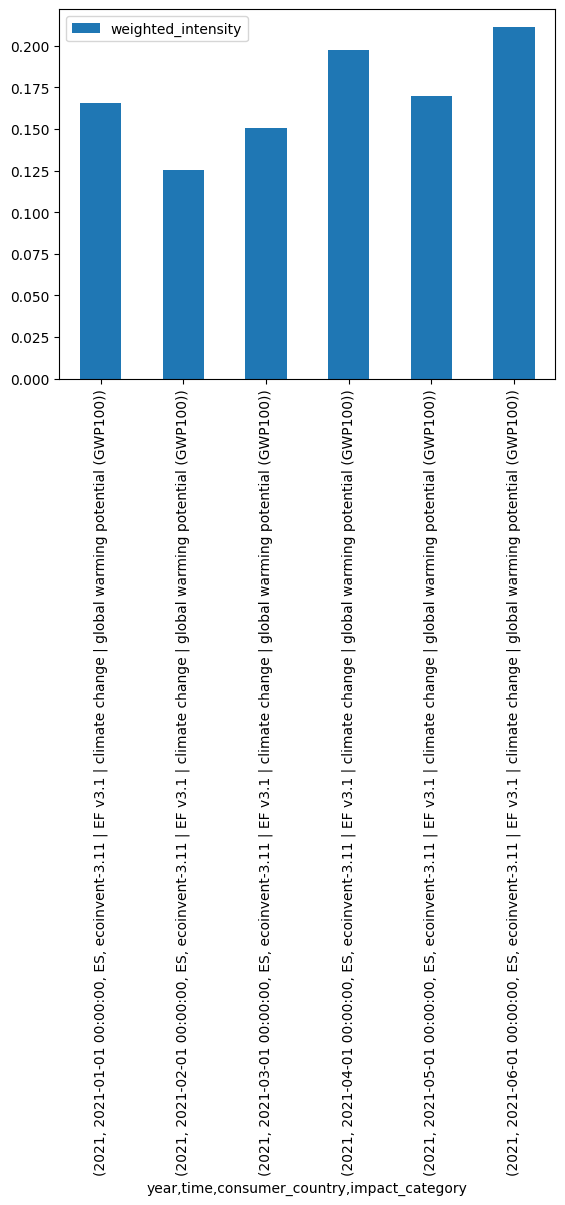

In [19]:
validated.monthly().to_dataframe().plot.bar()

In [30]:
gwp_bw = (
    validated.hourly()
    .to_dataframe()["intensity"]
    .droplevel(["consumer_country", "impact_category"])
)

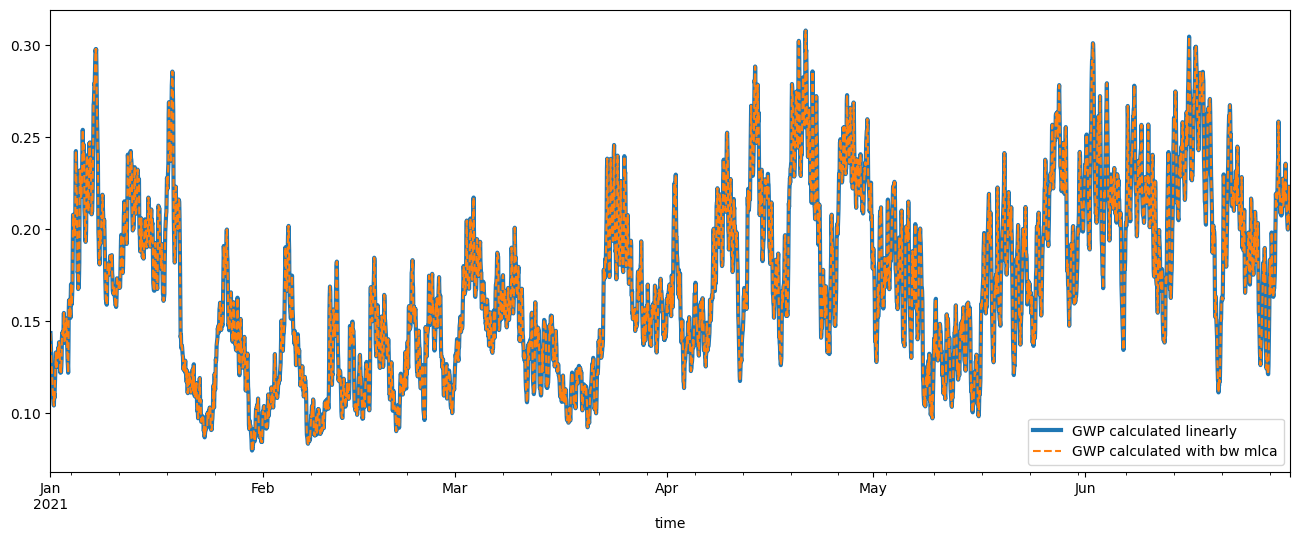

In [36]:
ax = gwp_linear.plot(figsize=(16, 6), linewidth=3)
gwp_bw.plot(ax=ax, linestyle="--")
ax.legend(["GWP calculated linearly", "GWP calculated with bw mlca"])